In [1]:
import os
import sys

from copy import deepcopy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
path_this = os.path.dirname(os.path.abspath(__name__))
path_root= os.path.join(path_this, '..')
path_dataset = os.path.join(path_root, 'data')

In [3]:
import pandas as pd

df_dataset = pd.read_csv(os.path.join(path_dataset,'dataset.csv'))
# df_backup = deepcopy(df_dataset)
df_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
feature_desc = {
	"categorical": [
		# Membership Details
		'customerID', 'Contract', 'PaymentMethod', 'PaperlessBilling',
		# Demograph
		'gender', 'SeniorCitizen', 'Partner', 'Dependents',
		# Service
		'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
		'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PhoneService',
		# target 
		'Churn'],
	"numeric": ['tenure', 'MonthlyCharges', 'TotalCharges']
}

In [5]:
def preprocess_churn_col(value:str):
	if isinstance(value, int):
		return value
	elif value.lower() == 'yes':
		return 1
	elif value.lower() == 'no':
		return 0

In [6]:
df_dataset['TotalCharges'] = pd.to_numeric(df_dataset['TotalCharges'], errors='coerce')
df_dataset['Churn'] = df_dataset['Churn'].map(preprocess_churn_col)
df_dataset = df_dataset.loc[df_dataset['tenure'] != 0].reset_index(drop=True)
df_dataset.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Decision Tree Modelling

In [7]:
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
	classification_report, roc_auc_score, confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df_decision_tree = deepcopy(df_dataset)
df_decision_tree.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [51]:
TARGET = 'Churn'
X = df_decision_tree.drop(columns=[
	TARGET, 'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'TotalCharges'
	])
y = df_decision_tree[TARGET]
y.value_counts(dropna=False, normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [58]:
categorical_features = X.select_dtypes(include='object').columns.to_list()
numerical_features = X.select_dtypes(exclude='object').columns.to_list()

In [59]:
preprocessor = ColumnTransformer(
	transformers=[
		('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
		('num', "passthrough", numerical_features)
	]
)

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

In [60]:
pipeline = Pipeline(
	steps=[
		('preprocess', preprocessor),
		('model', dt)
	]
)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    stratify=y, random_state=42
)


In [62]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [63]:
from sklearn.metrics import (
	accuracy_score, recall_score, precision_score, f1_score, confusion_matrix,
	classification_report, roc_auc_score, log_loss, RocCurveDisplay)


In [15]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.82      0.79      0.80      1033
           1       0.47      0.51      0.49       374

    accuracy                           0.72      1407
   macro avg       0.64      0.65      0.65      1407
weighted avg       0.73      0.72      0.72      1407

ROC-AUC: 0.6536126023057292


In [64]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.50      0.51      0.50       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.74      0.73      0.74      1407

ROC-AUC: 0.6630420715324763


In [66]:
param_grid = {
	'model__max_depth': [3, 5, 7, 10],
    "model__min_samples_leaf": [1, 5, 10],
    "model__criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
	pipeline, param_grid=param_grid, 
	scoring='roc_auc', cv=5, n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [67]:
best_model = grid.best_estimator_
print("Best parameters:", grid.best_params_)

Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 5}


In [68]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7491115849324804
Precision: 0.5189873417721519
Recall: 0.767379679144385
F1 Score: 0.6192017259978425
ROC AUC: 0.8329886473642525
Log Loss: 0.548450889595128

Confusion Matrix:
 [[767 266]
 [ 87 287]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [69]:
feature_names = (
    grid.best_estimator_
    .named_steps["preprocess"]
    .get_feature_names_out()
)

importances = grid.best_estimator_.named_steps["model"].feature_importances_

feat_imp = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

feat_imp.head(10)


,feature,importance
26,cat__Contract_Month-to-month,0.569469
35,num__tenure,0.152724
6,cat__InternetService_Fiber optic,0.096249
36,num__MonthlyCharges,0.074904
27,cat__Contract_One year,0.026571
33,cat__PaymentMethod_Electronic check,0.023863
17,cat__TechSupport_No,0.021286
11,cat__OnlineBackup_No,0.008265
28,cat__Contract_Two year,0.007910
32,cat__PaymentMethod_Credit card (automatic),0.006345


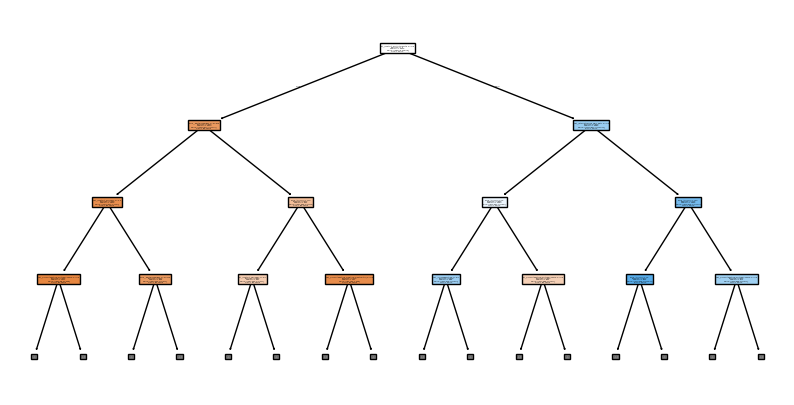

In [70]:
plt.figure(figsize=(10, 5))
plot_tree(
    grid.best_estimator_.named_steps["model"],
    feature_names=feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    max_depth=3
)
plt.show()


c:\Users\VICTUS\miniconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


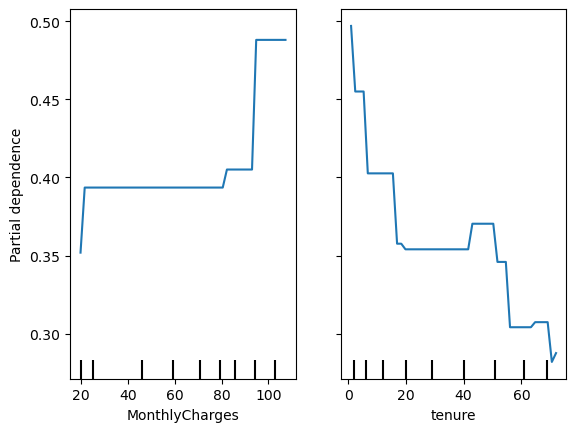

In [71]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    best_model,
    X_train,
    features=["MonthlyCharges", 'tenure'],
    kind="average",
    grid_resolution=50
)


In [72]:
tree = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()


In [73]:
from sklearn.tree import _tree

def extract_rules(tree, feature_names):
    tree_ = tree.tree_
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            feature = feature_names[tree_.feature[node]]
            threshold = tree_.threshold[node]

            recurse(tree_.children_left[node],
                    conditions + [f"{feature} <= {threshold:.2f}"])
            recurse(tree_.children_right[node],
                    conditions + [f"{feature} > {threshold:.2f}"])
        else:
            value = tree_.value[node][0]
            samples = tree_.n_node_samples[node]
            churn_rate = value[1] / value.sum()

            rules.append({
                "rule": "\nAND ".join(conditions),
                "samples": samples,
                "churn_rate": churn_rate
            })

    recurse(0, [])
    return rules


In [74]:
rules = extract_rules(tree, feature_names)

rules_df = (
    pd.DataFrame(rules)
    .sort_values("churn_rate", ascending=False)
)
rules_df.head()

,rule,samples,churn_rate
24,cat__Contract_Month-to-month > 0.50\nAND cat__...,182,0.952587
26,cat__Contract_Month-to-month > 0.50\nAND cat__...,358,0.876959
17,cat__Contract_Month-to-month > 0.50\nAND cat__...,251,0.790749
25,cat__Contract_Month-to-month > 0.50\nAND cat__...,276,0.774589
29,cat__Contract_Month-to-month > 0.50\nAND cat__...,416,0.743499


In [75]:
tree.tree_.n_node_samples

array([5625, 2540, 1906, 1041,  965,  605,  360,   76,   37,   39,  865,
        230,   89,  141,  635,  401,  234,  634,  507,  304,  292,   12,
        203,   17,  186,  127,   75,    8,   67,   52, 3085, 1390,  588,
        286,  140,  146,  302,  251,   51,  802,  543,  107,  436,  259,
        121,  138, 1695,  824,  190,    8,  182,  634,  276,  358,  871,
        391,  313,   78,  480,  416,   64])

In [76]:
high_risk_rules = rules_df[
    (rules_df["churn_rate"] > 0.6) &
    (rules_df["samples"] > 0.05 * len(X_train))
]

high_risk_rules.head(5)


,rule,samples,churn_rate
26,cat__Contract_Month-to-month > 0.50\nAND cat__...,358,0.876959
29,cat__Contract_Month-to-month > 0.50\nAND cat__...,416,0.743499
27,cat__Contract_Month-to-month > 0.50\nAND cat__...,313,0.609503


In [81]:
X.shape[0]

7032

In [77]:
def format_rule(rule):
    return (
        f"IF {rule['rule']}\n"
        f"THEN churn probability ≈ {rule['churn_rate']:.0%}\n"
        f"(Support: {rule['samples']} customers)"
    )

for _, r in high_risk_rules.iterrows():
    print(format_rule(r))
    print("-" * 80)


IF cat__Contract_Month-to-month > 0.50
AND cat__InternetService_Fiber optic > 0.50
AND num__tenure <= 15.50
AND num__tenure > 1.50
AND num__MonthlyCharges > 80.58
THEN churn probability ≈ 88%
(Support: 358 customers)
--------------------------------------------------------------------------------
IF cat__Contract_Month-to-month > 0.50
AND cat__InternetService_Fiber optic > 0.50
AND num__tenure > 15.50
AND cat__PaymentMethod_Electronic check > 0.50
AND num__tenure <= 55.50
THEN churn probability ≈ 74%
(Support: 416 customers)
--------------------------------------------------------------------------------
IF cat__Contract_Month-to-month > 0.50
AND cat__InternetService_Fiber optic > 0.50
AND num__tenure > 15.50
AND cat__PaymentMethod_Electronic check <= 0.50
AND num__tenure <= 51.50
THEN churn probability ≈ 61%
(Support: 313 customers)
--------------------------------------------------------------------------------


---

# Random Forest Modelling

In [30]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [31]:
df_random_forest = deepcopy(df_dataset)
df_random_forest.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [32]:
X = df_random_forest.drop(columns=['customerID', 'Churn'])
y = df_random_forest['Churn']

num_features = X.select_dtypes(exclude='object').columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

In [33]:
preprocessor = ColumnTransformer([
	('num', 'passthrough', num_features),
	('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
])

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, random_state=42, stratify=y, test_size=0.2)

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
rfc = RandomForestClassifier(
	n_estimators=300,
	max_depth=None, min_samples_leaf=20,
	class_weight='balanced', random_state=42,
	n_jobs=-1
)

pipeline = Pipeline([
	('preprocess', preprocessor),
	('model', rfc)
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, log_loss

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))
# print("ROC AUC:", roc_auc_score(y_test, y_prob))
# print("Log Loss:", log_loss(y_test, y_prob))


Accuracy: 0.751954513148543
Precision: 0.5220458553791887
Recall: 0.7914438502673797
F1 Score: 0.6291179596174282
ROC AUC: 0.8408366162622753
Log Loss: 0.4866150736536149

Confusion Matrix:
 [[762 271]
 [ 78 296]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.74      0.81      1033
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [41]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score, roc_auc_score, log_loss

scoring = {
    "accuracy": "accuracy",
    "recall": make_scorer(recall_score),
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_result = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

pd.DataFrame(cv_result).mean()


fit_time             0.377808
score_time           0.116903
test_accuracy        0.763200
test_recall          0.771906
test_roc_auc         0.848609
test_neg_log_loss   -0.475502
dtype: float64

In [45]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# print(classification_report(y_test, y_pred))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# from sklearn.metrics import roc_auc_score, log_loss

# print("ROC AUC:", roc_auc_score(y_test, y_prob))
# print("Log Loss:", log_loss(y_test, y_prob))


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.751954513148543
Precision: 0.5220458553791887
Recall: 0.7914438502673797
F1 Score: 0.6291179596174282
ROC AUC: 0.8408366162622753
Log Loss: 0.48661507365361495

Confusion Matrix:
 [[762 271]
 [ 78 296]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.74      0.81      1033
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [22]:
from sklearn.model_selection import GridSearchCV

In [46]:
param_grid = {
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [10, 20, 50],
    "model__max_features": ["sqrt", 0.5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="neg_log_loss",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)
grid.best_params_


{'model__max_depth': 12,
 'model__max_features': 0.5,
 'model__min_samples_leaf': 10}

In [47]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf = CalibratedClassifierCV(
    grid.best_estimator_,
    method="isotonic",
    cv=3
)

calibrated_rf.fit(X_train, y_train)

y_prob_cal = calibrated_rf.predict_proba(X_test)[:, 1]

print("Calibrated Log Loss:", log_loss(y_test, y_prob_cal))


Calibrated Log Loss: 0.4228423523196653


In [48]:
import numpy as np

thresholds = np.linspace(0.2, 0.6, 50)

best_thr, best_recall = 0, 0

for t in thresholds:
    y_pred_thr = (y_prob_cal >= t).astype(int)
    r = recall_score(y_test, y_pred_thr)
    if r > best_recall:
        best_recall = r
        best_thr = t

best_thr, best_recall


(np.float64(0.2), 0.8529411764705882)

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
	roc_curve,
    log_loss,
    confusion_matrix,
    classification_report
)

In [50]:
# y_pred_thr = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred_thr_thr = (y_prob_cal >= t).astype(int)

print("Accuracy:", round(accuracy_score(y_test, y_pred_thr), 3))
print("Precision:", round(precision_score(y_test, y_pred_thr), 3))
print("Recall:", round(recall_score(y_test, y_pred_thr), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_thr), 3))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("Log Loss:", round(log_loss(y_test, y_prob), 3))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_thr))
print(classification_report(y_test, y_pred_thr))

Accuracy: 0.79
Precision: 0.737
Recall: 0.329
F1 Score: 0.455
ROC AUC: 0.829
Log Loss: 0.555

Confusion Matrix:
 [[989  44]
 [251 123]]
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      1033
           1       0.74      0.33      0.45       374

    accuracy                           0.79      1407
   macro avg       0.77      0.64      0.66      1407
weighted avg       0.78      0.79      0.76      1407



In [35]:
recall_score(y_test, y_pred_thr)

0.32887700534759357